In [1]:
from pathlib import Path
from IPython.display import display, Markdown

from resources.imports import *
import torch

from resources.MLmodels import MODEL
from resources.MLmetrics import (
    postprocess_resolve_artifacts,
    postprocess_list_runs,
    postprocess_load_artifacts,
    postprocess_load_data,
    postprocess_available_evaluations,
    postprocess_attach_results,
    postprocess_build_diagnostics,
    print_field_diagnostics,
    plot_field_frame_component_trends,
    plot_field_frame_component_heatmaps,
    plot_field_diversity,
    plot_field_node_metrics,
    plot_field_sample_metric_distributions,
    plot_field_sample,
)

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


In [2]:
%load_ext autoreload
%autoreload 2

# ML Field Post-Processing

## Find Recent Runs

In [3]:
FIND_RUN = False
RUN_ROOT = Path(r"Z:/p2")

if FIND_RUN:
    recent_runs = postprocess_list_runs(RUN_ROOT, max_runs=25, include_hpo=True)
    display(recent_runs)
    if recent_runs.empty:
        raise ValueError("No saved runs were found. Set RUN_PATH manually.")

## 1. User Configuration

Set the run identity here. `run_type` controls whether the path points to a standard run, a model-specific HPO run, or one model inside a cross-model HPO run.

In [4]:
mechMode = "UT"
model = "Transformer"
run_name = "TR-Field-UT-1"
VIEW_MODE = None
run_type = "standard"  # "standard", "model_hpo", or "cross_model_hpo"
RUN_PATH_OVERRIDE = None

if RUN_PATH_OVERRIDE is not None:
    RUN_PATH = Path(RUN_PATH_OVERRIDE)
elif run_type == "standard":
    RUN_PATH = RUN_ROOT / mechMode / model / run_name
elif run_type == "model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / model / "HPO" / run_name
elif run_type == "cross_model_hpo":
    RUN_PATH = RUN_ROOT / mechMode / "HPO" / run_name / model
else:
    raise ValueError("run_type must be 'standard', 'model_hpo', or 'cross_model_hpo'.")

DATA_PATH_OVERRIDE = None

if VIEW_MODE is None:
    VIEW_MODE = mechMode if str(mechMode).upper() in ["UT", "FT"] else "UT"
VIEW_MODE = str(VIEW_MODE).upper()
if VIEW_MODE not in ["UT", "FT"]:
    raise ValueError("VIEW_MODE must be UT or FT. For MULTI runs, choose which output branch to view.")

LOAD_DATA = True
LOAD_MODEL = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

ACTIVE_SPLIT = None


## 3. Load Run Artifacts

In [5]:
artifacts = postprocess_resolve_artifacts(
    RUN_PATH,
    run_root=RUN_ROOT,
)

artifact_columns = ["artifact", "path_or_value"]
artifact_rows = []
for key in ["input_path", "run_dir", "model_json", "model_mdl", "data_json", "results_dir", "metrics_json", "predictions_npz", "loss_history_csv", "diagnostics_summary_json", "is_hpo"]:
    value = artifacts.get(key)
    artifact_rows.append((key, str(value) if value is not None else None))
display(pd.DataFrame(artifact_rows, columns=artifact_columns))

for warning in artifacts.get("warnings", []):
    print("WARNING:", warning)

loaded = postprocess_load_artifacts(artifacts)

DAT = None
if LOAD_DATA and artifacts.get("data_json") is not None:
    try:
        DAT = postprocess_load_data(
            artifacts["data_json"],
            data_path_override=DATA_PATH_OVERRIDE,
            auto_path_root=RUN_ROOT,
        )
        print("Loaded DATA from:", artifacts["data_json"])
        print("DATA output_kind:", getattr(DAT, "output_kind", "curve"))
    except Exception as exc:
        print("DATA load failed:", repr(exc))

MOD = None
if LOAD_MODEL and artifacts.get("model_json") is not None and DAT is not None:
    try:
        MOD = MODEL.from_json(
            artifacts["model_json"],
            data=DAT,
            load_weights=artifacts.get("model_mdl") is not None,
            model_path=str(artifacts["model_mdl"]) if artifacts.get("model_mdl") is not None else None,
            device=DEVICE,
            scan_matches_on_init=False,
        )
        MOD = postprocess_attach_results(MOD, loaded)
        print("Loaded MODEL from:", artifacts["model_json"])
    except Exception as exc:
        print("MODEL load failed:", repr(exc))
elif LOAD_MODEL:
    print("MODEL was not loaded because a model JSON or DATA object is missing.")


,artifact,path_or_value
0,input_path,Z:\p2\UT\Transformer\TR-Field-UT-1
1,run_dir,Z:\p2\UT\Transformer\TR-Field-UT-1
2,model_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model.json
3,model_mdl,Z:\p2\UT\Transformer\TR-Field-UT-1\model.mdl
4,data_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model_data....
5,results_dir,Z:\p2\UT\Transformer\TR-Field-UT-1\results
6,metrics_json,Z:\p2\UT\Transformer\TR-Field-UT-1\results\met...
7,predictions_npz,Z:\p2\UT\Transformer\TR-Field-UT-1\results\pre...
8,loss_history_csv,NaN
9,diagnostics_summary_json,Z:\p2\UT\Transformer\TR-Field-UT-1\results\dia...


Loaded DATA from: Z:\p2\UT\Transformer\TR-Field-UT-1\model_data.json
DATA output_kind: field
Loaded MODEL from: Z:\p2\UT\Transformer\TR-Field-UT-1\model.json


## 5. Run Setup And Available Outputs

In [6]:
RUN_SUMMARY_FIELDS = [
    "run",
    "run_type",
    "mechMode",
    "VIEW_MODE",
    "model",
    "output_kind",
    "device",
    "evaluation_split",
    "is_hpo",
    "model_json",
    "results_dir",
]
MODEL_SETUP_FIELDS = ["model_type", "name", "in_size", "out_size", "hidden_size", "n_layers", "n_heads", "dropout"]
ACTIVE_METRIC_KEYS = ["best_epoch", "best_loss", "best_mse", "best_rmse", "mae", "mse", "rmse", "best", "worst"]
FIELD_EVAL_COLUMNS = ["mode", "split", "outputs", "truth", "sample_metrics", "frame_metrics", "component_metrics", "node_metrics"]


descriptor = loaded.get("descriptor") or {}
data_descriptor = loaded.get("data_descriptor") or {}
metrics = loaded.get("metrics") or {}
hpo = loaded.get("hpo") or {}


def _nested_get(mapping, keys, default=None):
    value = mapping
    for key in keys:
        if not isinstance(value, dict) or key not in value:
            return default
        value = value[key]
    return value


def _descriptor_output_kind(data_descriptor):
    if not isinstance(data_descriptor, dict):
        return None
    cfg = data_descriptor.get("data_config", data_descriptor.get("config", data_descriptor))
    return cfg.get("output_kind") if isinstance(cfg, dict) else None


saved_output_kind = _descriptor_output_kind(data_descriptor)
loaded_output_kind = getattr(DAT, "output_kind", None) if DAT is not None else saved_output_kind
if loaded_output_kind is not None and str(loaded_output_kind).lower() != "field":
    print("WARNING: this notebook is intended for field-output runs, but the selected run does not look like output_kind='field'.")

summary_values = {
    "run": run_name,
    "run_type": run_type,
    "mechMode": mechMode,
    "VIEW_MODE": VIEW_MODE,
    "model": model,
    "output_kind": loaded_output_kind,
    "device": DEVICE,
    "evaluation_split": metrics.get("evaluation_split"),
    "is_hpo": artifacts.get("is_hpo"),
    "model_json": artifacts.get("model_json"),
    "results_dir": artifacts.get("results_dir"),
}
display(pd.DataFrame([(key, summary_values.get(key)) for key in RUN_SUMMARY_FIELDS], columns=["item", "value"]))

run_descriptor = descriptor.get("run_descriptor") if isinstance(descriptor, dict) else None
if isinstance(run_descriptor, dict):
    compact_descriptor = {
        "model_type": descriptor.get("model_type"),
        "name": descriptor.get("name"),
        "in_size": run_descriptor.get("in_size"),
        "out_size": run_descriptor.get("out_size"),
        "hidden_size": run_descriptor.get("hidden_size"),
        "n_layers": run_descriptor.get("n_layers"),
        "n_heads": run_descriptor.get("n_heads"),
        "dropout": run_descriptor.get("dropout"),
    }
    compact_descriptor = {k: v for k, v in compact_descriptor.items() if k in MODEL_SETUP_FIELDS and v is not None}
    if compact_descriptor:
        display(Markdown("### Model Setup"))
        display(pd.DataFrame(compact_descriptor.items(), columns=["item", "value"]))

metric_rows = []
if metrics:
    for key in [f"{VIEW_MODE}_{metric}" for metric in ACTIVE_METRIC_KEYS]:
        if key in metrics:
            metric_rows.append((key, metrics[key]))
if metric_rows:
    display(Markdown("### Saved Metrics For Active View"))
    display(pd.DataFrame(metric_rows, columns=["metric", "value"]))

available_evals = postprocess_available_evaluations(loaded)
available_field_evals = available_evals[[col for col in FIELD_EVAL_COLUMNS if col in available_evals.columns]]
display(Markdown("### Available Field Predictions / Diagnostic Tables"))
display(available_field_evals)

if ACTIVE_SPLIT is None:
    ACTIVE_SPLIT = metrics.get("evaluation_split", None)
if ACTIVE_SPLIT is None and not available_evals.empty:
    matching = available_evals[available_evals["mode"].astype(str).str.upper() == str(VIEW_MODE).upper()]
    ACTIVE_SPLIT = (matching.iloc[0] if not matching.empty else available_evals.iloc[0])["split"]

print("mechMode:", mechMode)
print("VIEW_MODE:", VIEW_MODE)
print("ACTIVE_SPLIT:", ACTIVE_SPLIT)

if hpo:
    display(Markdown("### HPO Summary"))
    for key, value in hpo.items():
        if isinstance(value, dict):
            display(Markdown(f"#### {key}"))
            display(pd.DataFrame(value.items(), columns=["parameter", "value"]))
else:
    print("No HPO files were found for this run.")


,item,value
0,run,TR-Field-UT-1
1,run_type,standard
2,mechMode,UT
3,VIEW_MODE,UT
4,model,Transformer
5,output_kind,field
6,device,cpu
7,evaluation_split,test
8,is_hpo,False
9,model_json,Z:\p2\UT\Transformer\TR-Field-UT-1\model.json


### Saved Metrics For Active View

,metric,value
0,UT_best_epoch,24
1,UT_best_loss,0.013058
2,UT_best_mse,0.013058
3,UT_best_rmse,"[False, 0.11427342798177295]"
4,UT_mae,0.466538
5,UT_mse,0.989384
6,UT_rmse,0.994678
7,UT_best,124
8,UT_worst,188


### Available Field Predictions / Diagnostic Tables

,mode,split,outputs,truth,sample_metrics,frame_metrics,component_metrics,node_metrics
0,UT,test,True,True,True,True,True,True


mechMode: UT
VIEW_MODE: UT
ACTIVE_SPLIT: test
No HPO files were found for this run.


## 7. Build Active Field Diagnostics

In [7]:
diagnostics = {}

for _, row in available_evals.iterrows():
    mode = str(row["mode"]).upper()
    split = str(row["split"]).lower()

    diag = postprocess_build_diagnostics(
        DAT,
        loaded,
        mode=mode,
        split=split,
        prefer_saved_tables=True,
        recompute_from_predictions=False,
    )
    if diag is None:
        print(f"No saved diagnostics are available for {mode} {split}.")
        continue
    if "field_shape" not in diag:
        print(f"Skipping {mode} {split}: diagnostics are not field diagnostics.")
        continue

    diagnostics[(mode, split)] = diag
    if MOD is not None:
        setattr(MOD, f"{mode}_{split}_diagnostics", diag)
        if split == "test":
            setattr(MOD, f"{mode}_diagnostics", diag)
            setattr(MOD, f"{mode}_prediction_summary", diag.get("summary"))

active_key = (str(VIEW_MODE).upper(), str(ACTIVE_SPLIT).lower()) if VIEW_MODE and ACTIVE_SPLIT else None
active_diag = diagnostics.get(active_key) if active_key is not None else None

if active_diag is None:
    print("No active diagnostics are available. Check predictions.npz, diagnostic CSVs, VIEW_MODE, or ACTIVE_SPLIT.")
else:
    print_field_diagnostics(active_diag, label=f"{active_key[0]} {active_key[1]}")


UT test prediction diagnostics | RMSE: 0.9947 | MAE: 0.4665 | mean-field RMSE: 1.074 | skill vs mean field: 0.0742 | collapse ratio: 0.466 | valid: 1


## 8. Active Diagnostic Summary

In [8]:
SUMMARY_METRICS = [
    "rmse",
    "mae",
    "mse",
    "bias",
    "collapse_ratio",
    "mean_field_baseline_rmse",
    "skill_vs_mean_field_rmse",
    "valid_fraction",
    "n_samples",
    "n_frames",
    "n_nodes",
    "n_components",
]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    summary = active_diag.get("summary", {})
    summary_rows = [(key, summary.get(key)) for key in SUMMARY_METRICS if key in summary]
    display(pd.DataFrame(summary_rows, columns=["metric", "value"]))


,metric,value
0,rmse,0.994678
1,mae,0.466538
2,mse,0.989384
3,bias,-0.025421
4,collapse_ratio,0.466498
5,mean_field_baseline_rmse,1.074383
6,skill_vs_mean_field_rmse,0.074187
7,valid_fraction,0.999944
8,n_samples,889.000000
9,n_frames,20.000000


## 9. Frame And Component Performance

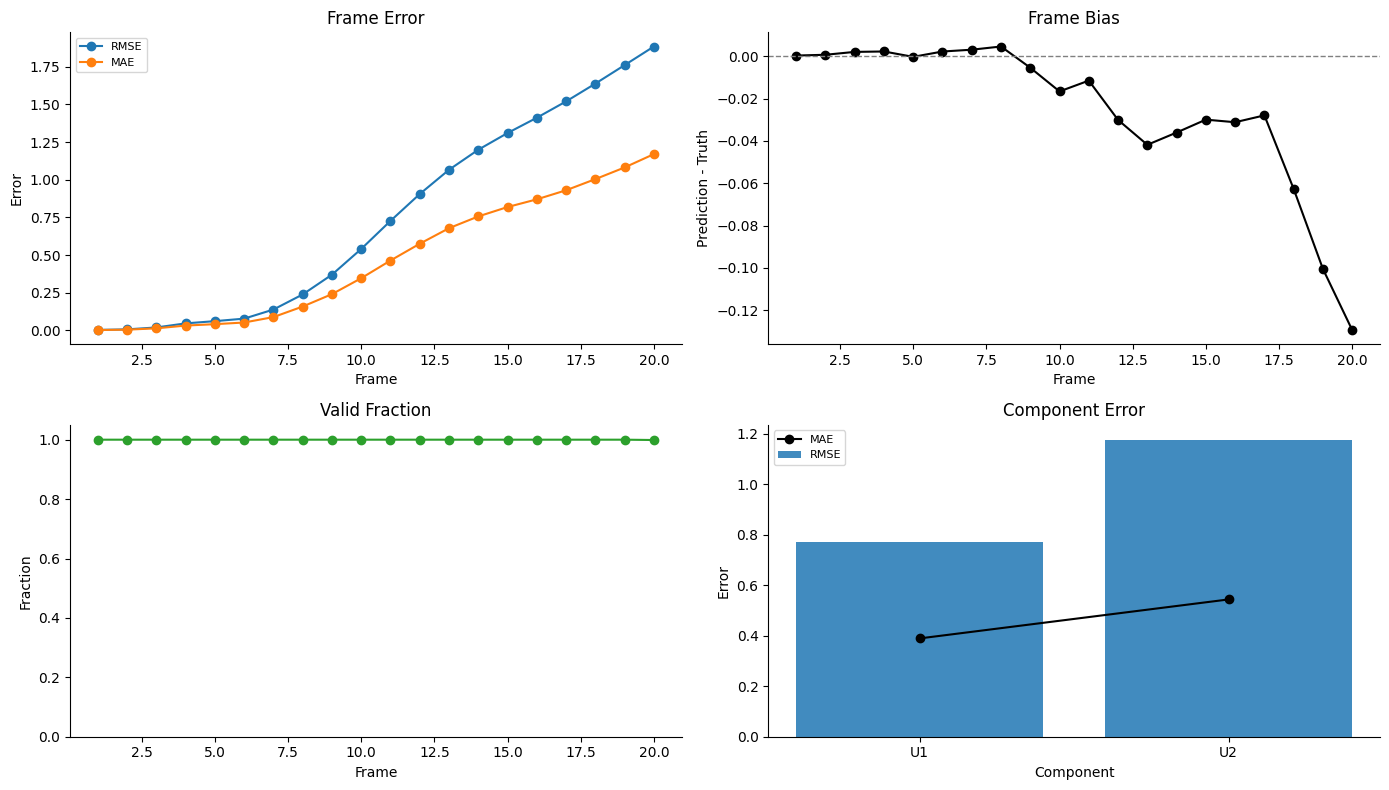

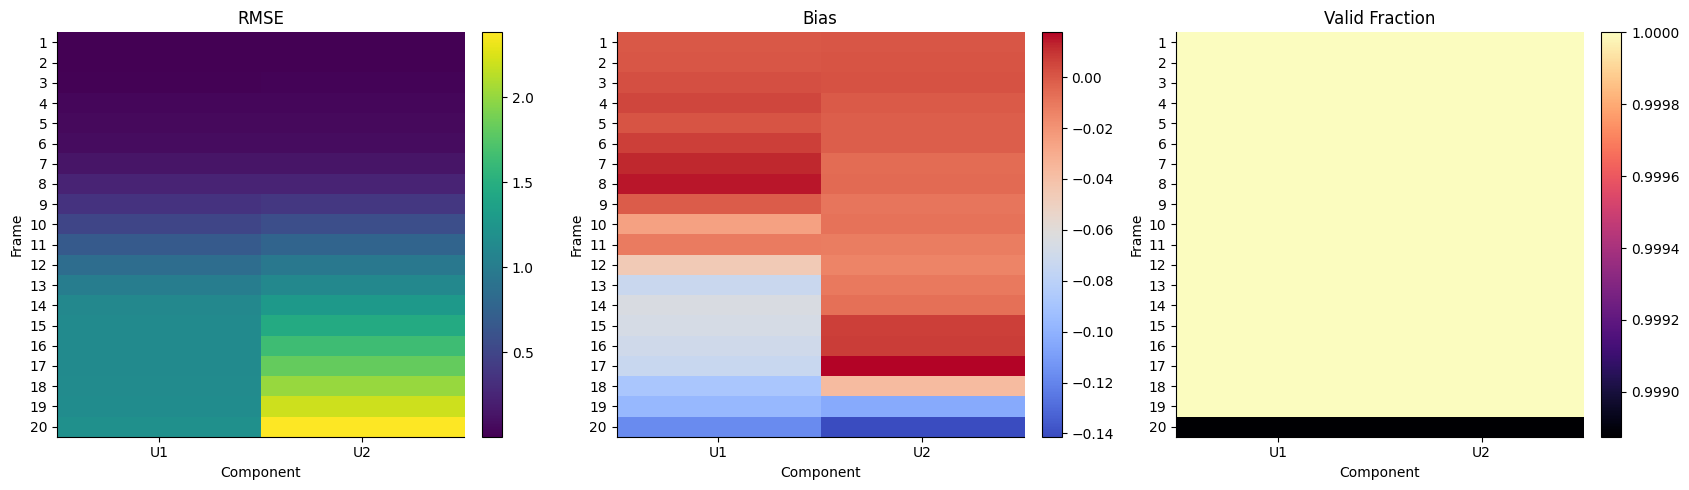

### Component Metrics

,component,mae,mse,rmse,bias,valid_fraction
0,U1,0.389376,0.595084,0.771417,-0.034569,0.999944
1,U2,0.543701,1.383684,1.176301,-0.016272,0.999944


In [9]:
FRAME_TRENDS_FIGSIZE = (14, 8)
HEATMAP_FIGSIZE = (17, 5)
HEATMAP_CMAPS = {"RMSE": "viridis", "Bias": "coolwarm", "Valid Fraction": "magma"}
SHOW_COMPONENT_TABLE = True


if active_diag is None:
    print("No active diagnostics are available.")
else:
    plot_field_frame_component_trends(active_diag, figsize=FRAME_TRENDS_FIGSIZE)
    plot_field_frame_component_heatmaps(active_diag, figsize=HEATMAP_FIGSIZE, cmaps=HEATMAP_CMAPS)

    component_metrics = active_diag.get("component_metrics")
    if SHOW_COMPONENT_TABLE and hasattr(component_metrics, "copy"):
        display(Markdown("### Component Metrics"))
        display(component_metrics)


## 10. Prediction Collapse And Field Diversity

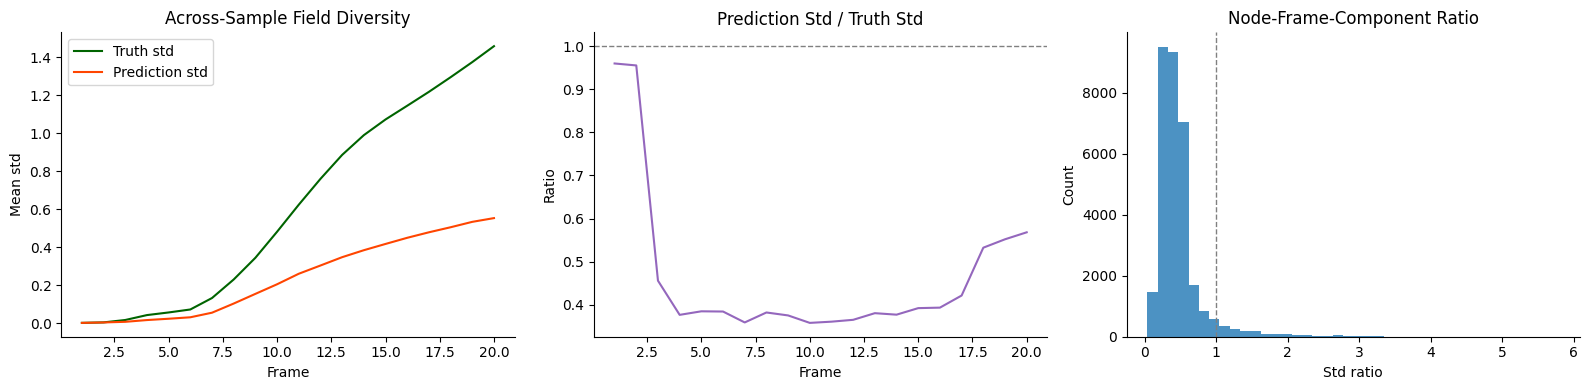

In [10]:
DIVERSITY_FIGSIZE = (16, 4)
DIVERSITY_RATIO_REFERENCE = 1.0
DIVERSITY_BINS = 40


if active_diag is None:
    print("No active diagnostics are available.")
else:
    try:
        plot_field_diversity(
            active_diag,
            figsize=DIVERSITY_FIGSIZE,
            ratio_reference=DIVERSITY_RATIO_REFERENCE,
            bins=DIVERSITY_BINS,
        )
    except ValueError as exc:
        print(exc)


## 11. Sample-Level Error

### Best And Worst Samples By RMSE

,sample,sample_mae,sample_mse,sample_rmse,sample_bias,valid_fraction
124,124,0.144992,0.105882,0.325395,0.031977,1.0
439,439,0.147003,0.123755,0.351788,-0.029317,1.0
543,543,0.168522,0.142175,0.377061,-0.045570,1.0
266,266,0.224071,0.157161,0.396435,-0.055241,1.0
75,75,0.197795,0.186239,0.431554,-0.096576,1.0
79,79,0.760319,2.593667,1.610486,0.034828,1.0
274,274,0.807280,2.704283,1.644470,-0.016764,1.0
885,885,0.749226,2.817799,1.678630,-0.041264,1.0
307,307,0.778348,2.892177,1.700640,-0.021492,1.0
188,188,0.807762,3.082390,1.755674,-0.196135,1.0


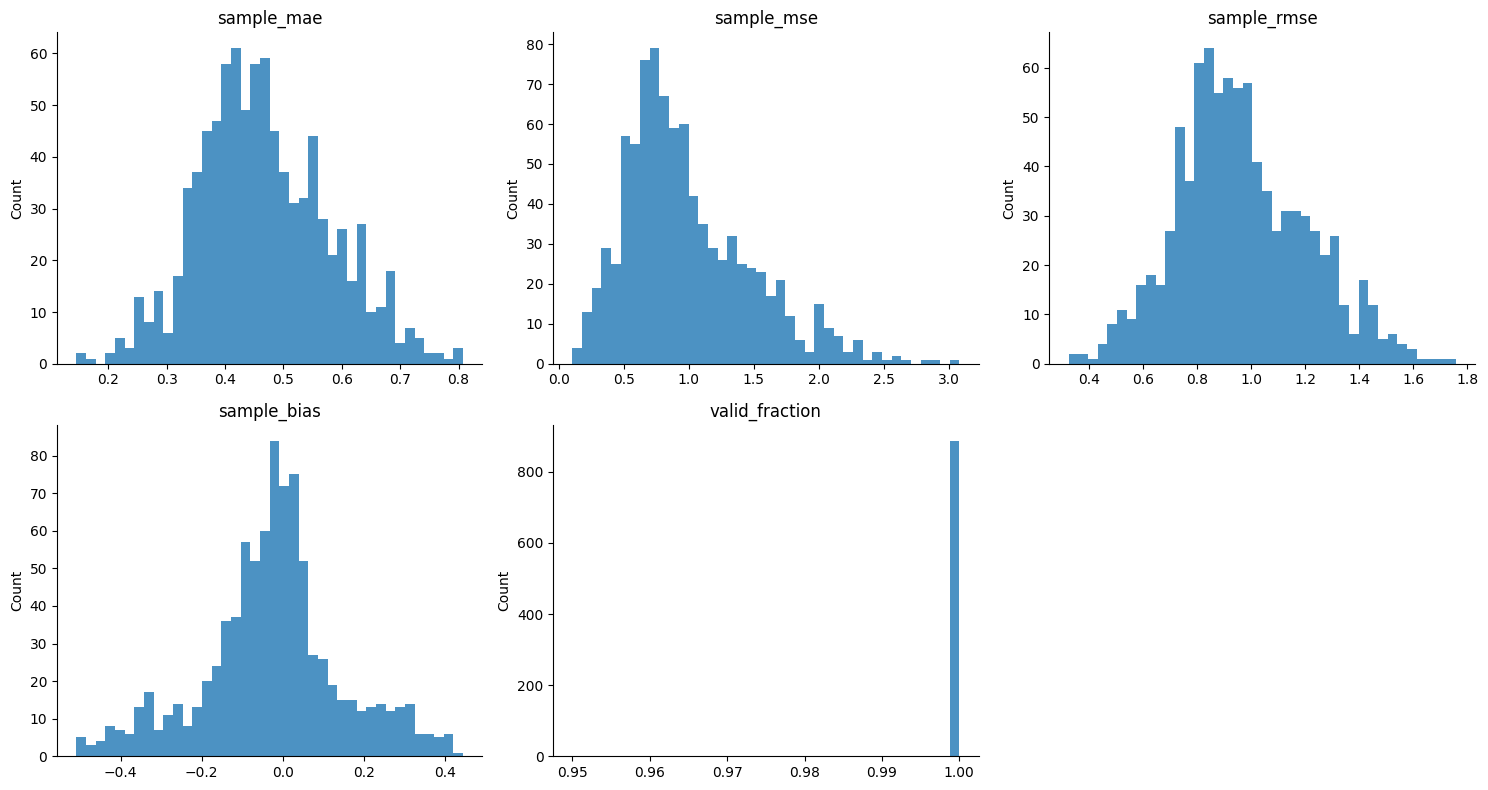

### Sample Metric Summary

,count,mean,std,min,25%,50%,75%,max
sample_mae,889.0,0.466546,0.112216,0.144992,0.388927,0.456164,0.543241,0.807762
sample_mse,889.0,0.989419,0.491232,0.105882,0.648856,0.886388,1.269479,3.082390
sample_rmse,889.0,0.965119,0.240892,0.325395,0.805516,0.941482,1.126712,1.755674
sample_bias,889.0,-0.025411,0.172307,-0.509636,-0.110685,-0.021047,0.053976,0.444765
valid_fraction,889.0,0.999944,0.001677,0.950000,1.000000,1.000000,1.000000,1.000000


In [11]:
SAMPLE_DISTRIBUTION_BINS = 40
SAMPLE_DISTRIBUTION_NCOLS = 3
SAMPLE_TABLE_TOP_N = 5
SAMPLE_DESCRIBE_COLUMNS = ["sample_mae", "sample_mse", "sample_rmse", "sample_bias", "valid_fraction"]


if active_diag is None:
    print("No active diagnostics are available.")
else:
    sample_metrics = active_diag.get("sample_metrics")
    if sample_metrics is None or not hasattr(sample_metrics, "copy"):
        print("Sample metrics are unavailable.")
    else:
        samples = sample_metrics.copy()
        if "sample_rmse" in samples.columns:
            display(Markdown("### Best And Worst Samples By RMSE"))
            best_worst = pd.concat([
                samples.sort_values("sample_rmse").head(SAMPLE_TABLE_TOP_N),
                samples.sort_values("sample_rmse").tail(SAMPLE_TABLE_TOP_N),
            ]).drop_duplicates()
            display(best_worst)

        try:
            plot_field_sample_metric_distributions(
                active_diag,
                columns=SAMPLE_DESCRIBE_COLUMNS,
                bins=SAMPLE_DISTRIBUTION_BINS,
                ncols=SAMPLE_DISTRIBUTION_NCOLS,
            )
        except ValueError as exc:
            print(exc)

        describe_cols = [col for col in SAMPLE_DESCRIBE_COLUMNS if col in samples.columns]
        if describe_cols:
            display(Markdown("### Sample Metric Summary"))
            display(samples[describe_cols].describe().T)


## 12. Node-Level Spatial Error

### Worst Nodes By rmse

,node,node_label,mae,mse,rmse,bias,valid_fraction,x,y
498,498,681,0.870172,2.373458,1.540603,-0.101580,0.999944,95.0,95.0
298,298,447,0.936271,2.354319,1.534379,0.034586,0.999944,115.0,95.0
476,476,659,0.869963,2.332276,1.527179,-0.061549,0.999944,105.0,95.0
701,701,929,0.896366,2.330958,1.526747,-0.174904,0.999944,85.0,95.0
339,339,489,0.972747,2.310766,1.520120,0.022515,0.999944,125.0,95.0
300,300,449,0.951852,2.290142,1.513321,-0.041549,0.999944,120.0,100.0
290,290,439,0.960258,2.282215,1.510700,0.065756,0.999944,130.0,90.0
296,296,445,0.922298,2.265441,1.505138,0.029788,0.999944,120.0,90.0
338,338,488,0.964961,2.260235,1.503408,0.041302,0.999944,130.0,100.0
223,223,349,0.958952,2.227476,1.492473,0.024226,0.999944,135.0,105.0


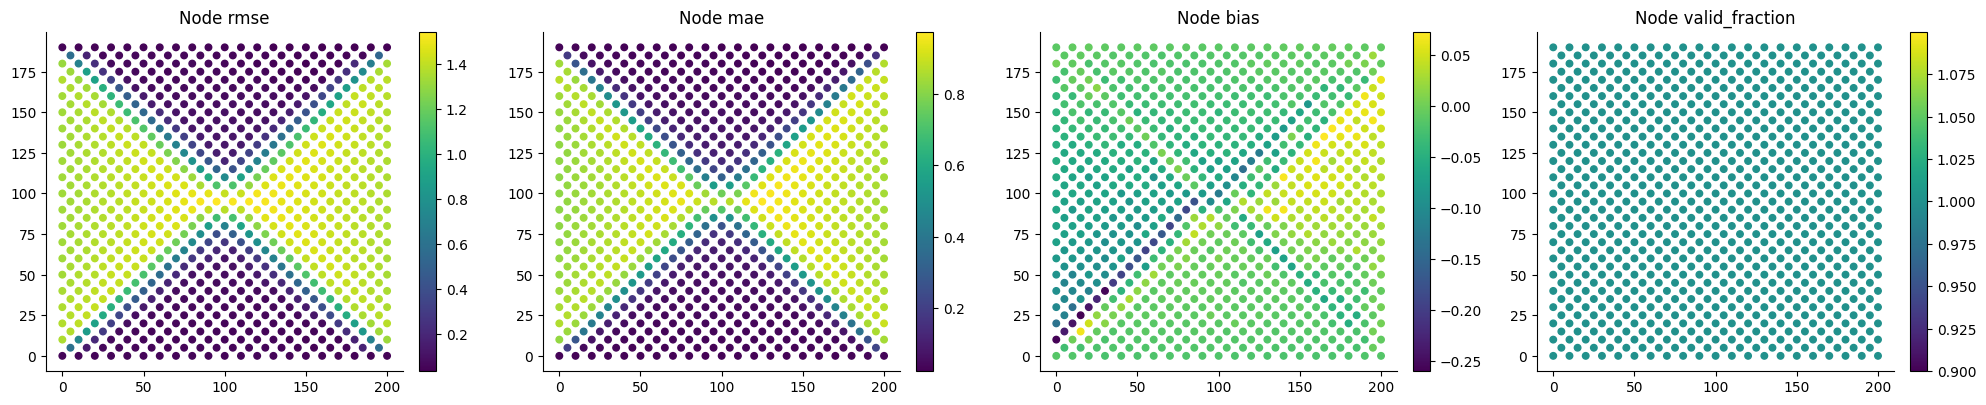

In [12]:
NODE_METRIC = "rmse"
NODE_TABLE_TOP_N = 20
NODE_PLOT_COLUMNS = ["rmse", "mae", "bias", "valid_fraction"]
NODE_POINT_SIZE = 22


if active_diag is None:
    print("No active diagnostics are available.")
else:
    node_metrics = active_diag.get("node_metrics")
    if node_metrics is None or not hasattr(node_metrics, "copy"):
        print("Node metrics are unavailable.")
    else:
        node = node_metrics.copy()
        metric = NODE_METRIC if NODE_METRIC in node.columns else "rmse"
        display(Markdown(f"### Worst Nodes By {metric}"))
        display(node.sort_values(metric, ascending=False).head(NODE_TABLE_TOP_N))

        try:
            plot_field_node_metrics(active_diag, columns=NODE_PLOT_COLUMNS, point_size=NODE_POINT_SIZE)
        except ValueError as exc:
            print(exc)


## 13. Interactive Field Viewer

In [27]:
FIELD_SAMPLE_MODE = "selected"
FIELD_SELECTED_SAMPLES = 0
FIELD_VIEW_FRAME = 10
FIELD_VIEW_COMPONENT = "U2"
FIELD_RANKING_METRIC = "rmse"
FIELD_PLOT_STYLE = "continuous"
FIELD_RANDOM_COUNT = 5


try:
    import ipywidgets as widgets
    widgets.Widget.close_all()
except Exception:
    widgets = None
_FIELD_VIEWER_STATE = {"last_key": None}


if active_diag is None:
    print("No active diagnostics are available.")
else:
    import ast
    from io import BytesIO
    from IPython.display import Image as IPyImage

    samples = active_diag["sample_metrics"].copy()
    coords = active_diag.get("node_coords")
    y_pred = np.asarray(active_diag["y_pred"], dtype=float)
    n_samples, n_frames, _, n_components = y_pred.shape
    components = [str(c) for c in active_diag.get("components", [f"c{i}" for i in range(n_components)])]
    metric_options = [metric for metric in ["rmse", "mae", "mse", "bias"] if f"sample_{metric}" in samples.columns]
    if not metric_options:
        metric_options = ["rmse"]

    def _as_sample_list(value):
        if isinstance(value, (int, np.integer)):
            return [int(value)]
        if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
            return [int(v) for v in list(value)]

        text = str(value).strip()
        if not text:
            return []
        try:
            parsed = ast.literal_eval(text)
            if isinstance(parsed, (int, np.integer)):
                return [int(parsed)]
            if isinstance(parsed, (list, tuple, set, np.ndarray)):
                return [int(v) for v in list(parsed)]
        except Exception:
            pass
        return [int(part.strip()) for part in text.replace(";", ",").split(",") if part.strip()]

    def _ranked_samples(metric, sample_mode, count=1):
        col = f"sample_{metric}"
        if col not in samples.columns:
            col = "sample_rmse"
        ranked = samples[["sample", col]].dropna().copy()
        if metric == "bias":
            ranked["_rank_value"] = ranked[col].abs()
        else:
            ranked["_rank_value"] = ranked[col]
        ranked = ranked.sort_values("_rank_value", ascending=(sample_mode == "best"))
        return ranked["sample"].astype(int).head(int(count)).tolist()

    def _sample_metric_text(sample_idx):
        row = samples.loc[samples["sample"].astype(int) == int(sample_idx)]
        if row.empty:
            return ""
        parts = []
        for metric in ["rmse", "mae", "mse", "bias"]:
            col = f"sample_{metric}"
            if col in row.columns:
                parts.append(f"{metric}={row[col].iloc[0]:.4g}")
        return ", " + ", ".join(parts) if parts else ""

    def _choose_samples(sample_mode, selected_samples, ranking_metric, random_count):
        if sample_mode == "selected":
            chosen = _as_sample_list(selected_samples)
        elif sample_mode in ["best", "worst"]:
            chosen = _ranked_samples(ranking_metric, sample_mode, count=1)
        elif sample_mode == "random":
            valid_samples = samples["sample"].astype(int).to_numpy()
            n_random = min(max(5, int(random_count)), len(valid_samples))
            chosen = np.random.default_rng().choice(valid_samples, size=n_random, replace=False).astype(int).tolist()
        else:
            chosen = []
        return [idx for idx in dict.fromkeys(chosen) if 0 <= int(idx) < n_samples]

    def _render_key(sample_mode, selected_samples, frame, component, ranking_metric, plot_style, random_count):
        return (sample_mode, str(selected_samples), int(frame), int(component), ranking_metric, plot_style, int(random_count))

    def _figure_png(fig):
        buffer = BytesIO()
        fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
        plt.close(fig)
        return IPyImage(data=buffer.getvalue())

    def _draw_field_samples(sample_mode, selected_samples, frame, component, ranking_metric, plot_style, random_count, out=None, force=False):
        render_key = _render_key(sample_mode, selected_samples, frame, component, ranking_metric, plot_style, random_count)
        if not force and render_key == _FIELD_VIEWER_STATE["last_key"]:
            return
        _FIELD_VIEWER_STATE["last_key"] = render_key

        def _write(text):
            if out is None:
                print(text)
            else:
                out.append_stdout(text + "\n")

        if coords is None:
            _write("Node coordinates are unavailable, so field sample maps cannot be drawn.")
            return
        if ranking_metric == "bias":
            _write("Bias = mean(prediction - truth); positive values over-predict and negative values under-predict.")

        frame_label = int(np.clip(frame, 1, n_frames))
        frame_idx = frame_label - 1
        component_idx = int(component)
        chosen = _choose_samples(sample_mode, selected_samples, ranking_metric, random_count)
        if not chosen:
            _write("No valid sample indices were selected.")
            return

        for sample_idx in chosen:
            _write(
                f"Sample {sample_idx}{_sample_metric_text(sample_idx)}, "
                f"frame={frame_label}, component={components[component_idx]}, style={plot_style}"
            )
            fig, _ = plot_field_sample(
                active_diag,
                sample=sample_idx,
                frame=frame_idx,
                component=component_idx,
                node_coords=coords,
                plot_style=plot_style,
                show=False,
            )
            if out is None:
                display(_figure_png(fig))
            else:
                out.append_display_data(_figure_png(fig))

    try:
        if widgets is None:
            import ipywidgets as widgets
        from IPython.display import clear_output, display

        sample_mode_widget = widgets.ToggleButtons(
            options=["selected", "best", "worst", "random"],
            value=FIELD_SAMPLE_MODE,
            description="Samples",
        )
        selected_samples_widget = widgets.Text(
            value=str(FIELD_SELECTED_SAMPLES),
            description="Selected",
            placeholder="0 or 0, 4, 12",
            layout=widgets.Layout(width="260px"),
        )
        frame_widget = widgets.IntSlider(
            value=int(np.clip(FIELD_VIEW_FRAME, 1, n_frames)),
            min=1,
            max=n_frames,
            step=1,
            description="",
            continuous_update=False,
            layout=widgets.Layout(width="190px"),
        )
        component_default = components.index(FIELD_VIEW_COMPONENT) if FIELD_VIEW_COMPONENT in components else (1 if n_components > 1 else 0)
        component_widget = widgets.Dropdown(
            options=[(name, idx) for idx, name in enumerate(components)],
            value=component_default,
            description="Component",
            layout=widgets.Layout(width="185px"),
            style={"description_width": "80px"},
        )
        metric_widget = widgets.Dropdown(
            options=metric_options,
            value=FIELD_RANKING_METRIC if FIELD_RANKING_METRIC in metric_options else metric_options[0],
            description="Rank by",
            layout=widgets.Layout(width="165px"),
            style={"description_width": "58px"},
        )
        plot_style_widget = widgets.ToggleButtons(
            options=["continuous", "points"],
            value=FIELD_PLOT_STYLE,
            description="Style",
            layout=widgets.Layout(width="320px", margin="0 0 0 28px"),
            style={"description_width": "48px"},
        )
        random_count_widget = widgets.BoundedIntText(
            value=min(max(5, int(FIELD_RANDOM_COUNT)), n_samples),
            min=min(5, n_samples),
            max=max(5, min(20, n_samples)),
            step=1,
            description="Random n",
            layout=widgets.Layout(width="150px"),
        )
        refresh_widget = widgets.Button(
            description="Refresh",
            button_style="primary",
            layout=widgets.Layout(width="80px", margin="0 0 0 16px"),
        )
        frame_label_widget = widgets.Label(
            value="Frame",
            layout=widgets.Layout(width="44px"),
        )
        frame_minus_widget = widgets.Button(
            description="-",
            layout=widgets.Layout(width="30px", margin="0 2px 0 0"),
        )
        frame_plus_widget = widgets.Button(
            description="+",
            layout=widgets.Layout(width="30px", margin="0 0 0 2px"),
        )
        frame_box = widgets.HBox(
            [frame_label_widget, frame_minus_widget, frame_widget, frame_plus_widget],
            layout=widgets.Layout(align_items="center", margin="0 14px 0 0"),
        )

        row1 = widgets.HBox([sample_mode_widget, selected_samples_widget, random_count_widget, refresh_widget])
        row2 = widgets.HBox(
            [frame_box, component_widget, metric_widget, plot_style_widget],
            layout=widgets.Layout(margin="12px 0 0 0"),
        )
        controls = widgets.VBox([row1, row2])
        output = widgets.Output()

        def _current_widget_values():
            return {
                "sample_mode": sample_mode_widget.value,
                "selected_samples": selected_samples_widget.value,
                "frame": frame_widget.value,
                "component": component_widget.value,
                "ranking_metric": metric_widget.value,
                "plot_style": plot_style_widget.value,
                "random_count": random_count_widget.value,
            }

        def _update_view(_=None, force=False):
            output.clear_output(wait=False)
            _draw_field_samples(**_current_widget_values(), out=output, force=force)

        def _step_frame(delta):
            frame_widget.value = int(np.clip(frame_widget.value + delta, frame_widget.min, frame_widget.max))

        frame_minus_widget.on_click(lambda _: _step_frame(-1))
        frame_plus_widget.on_click(lambda _: _step_frame(1))
        refresh_widget.on_click(lambda _: _update_view(force=True))

        for widget in [
            sample_mode_widget,
            selected_samples_widget,
            frame_widget,
            component_widget,
            metric_widget,
            plot_style_widget,
            random_count_widget,
        ]:
            widget.observe(lambda change: _update_view(force=True), names="value")

        display(controls, output)
        _update_view()
    except Exception as exc:
        print("ipywidgets are unavailable; using editable variables in this cell instead.")
        print(repr(exc))
        field_component = components.index(FIELD_VIEW_COMPONENT) if FIELD_VIEW_COMPONENT in components else (1 if n_components > 1 else 0)
        _draw_field_samples(
            FIELD_SAMPLE_MODE,
            FIELD_SELECTED_SAMPLES,
            FIELD_VIEW_FRAME,
            field_component,
            FIELD_RANKING_METRIC,
            FIELD_PLOT_STYLE,
            FIELD_RANDOM_COUNT,
        )


Output()

## 14. Selected Sample Frame Evolution

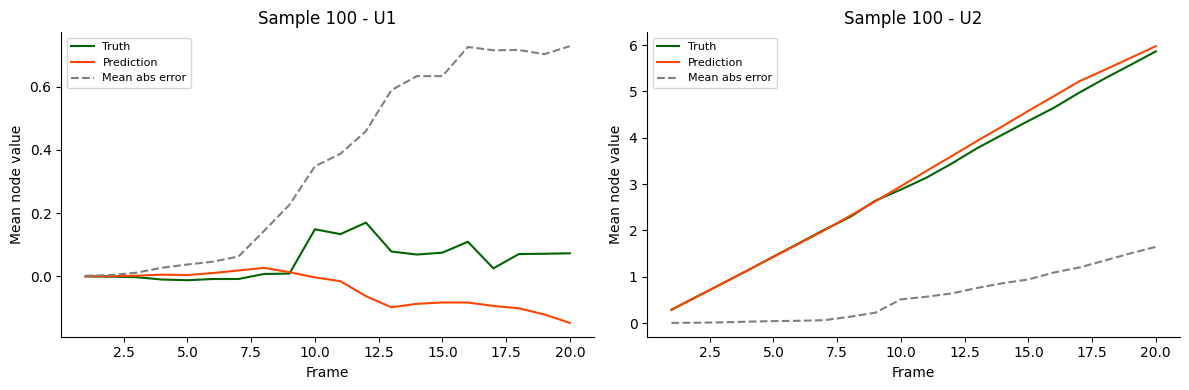

In [14]:
FRAME_EVOLUTION_SAMPLE = 100

if active_diag is not None:
    y_pred = np.asarray(active_diag["y_pred"], dtype=float)
    y_true = np.asarray(active_diag["y_true"], dtype=float)
    valid = np.asarray(active_diag.get("valid_mask", np.isfinite(y_true) & np.isfinite(y_pred)), dtype=bool)
    n_samples, n_frames, _, n_components = y_pred.shape
    sample_idx = int(np.clip(FRAME_EVOLUTION_SAMPLE, 0, n_samples - 1))
    x = np.arange(n_frames) + 1
    components = [str(c) for c in active_diag.get("components", [f"c{i}" for i in range(n_components)])]

    pred_s = np.where(valid[sample_idx], y_pred[sample_idx], np.nan)
    true_s = np.where(valid[sample_idx], y_true[sample_idx], np.nan)
    err_s = pred_s - true_s

    pred_mean = np.nanmean(pred_s, axis=1)
    true_mean = np.nanmean(true_s, axis=1)
    mae_frame = np.nanmean(np.abs(err_s), axis=1)

    fig, axes = plt.subplots(1, n_components, figsize=(6 * n_components, 4), squeeze=False)
    for comp_idx in range(n_components):
        ax = axes[0, comp_idx]
        ax.plot(x, true_mean[:, comp_idx], label="Truth", color="darkgreen")
        ax.plot(x, pred_mean[:, comp_idx], label="Prediction", color="orangered")
        ax.plot(x, mae_frame[:, comp_idx], label="Mean abs error", color="gray", linestyle="--")
        ax.set_title(f"Sample {sample_idx} - {components[comp_idx]}")
        ax.set_xlabel("Frame")
        ax.set_ylabel("Mean node value")
        ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 15. Training Loss History

In [15]:
LOSS_HISTORY_METRICS = ["train_loss", "val_loss"]
LOSS_HISTORY_FIGSIZE = (9, 4)


loss_history = loaded.get("loss_history")
if loss_history is None or not hasattr(loss_history, "empty") or loss_history.empty:
    print("No loss_history.csv was found for this run.")
else:
    display(loss_history.head())
    fig, ax = plt.subplots(figsize=LOSS_HISTORY_FIGSIZE)
    for mode, mode_history in loss_history.groupby("mode"):
        for metric in LOSS_HISTORY_METRICS:
            if metric in mode_history.columns:
                ax.plot(mode_history["epoch"], mode_history[metric], marker="o", label=f"{mode} {metric}")
    ax.set_title("Training History")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


No loss_history.csv was found for this run.
